<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE17-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/FA1-Problem%20Solving%20Activity-success?style=for-the-badge)

---

# Advanced Data Science [MCA33PE17]
## FA1 - Problem Solving Activity
### Topic: Feature Selection

---
<br>

| Field | Details |
|---|---|
| **Institute** | **Pimpri Chinchwad College of Engineering (PCCoE)** |
| **Department** | **MCA** |
| **Class / Year** | **SYMCA (Semester-I)** |
| **Academic Year** | **2026-2027** |
| **Assessment** | **FA1 - Problem Solving Activity (Max Marks: 20)** |
| **Assignment Date** | **17/08/2026** |
| **Date of Submission** | **02/09/2026** |
| **Student Name** | Amit Chame |
| **PRN** | 125M1H020 |
</div>

---
### Declaration
_I hereby declare that the work submitted in this FA1 assignment is my own and has not been copied from any other source._

---

## Problem Statement

Real-world datasets often contain a large number of features, and not all of them are equally useful for building a machine learning model. Some features carry duplicate information (they are highly correlated with other features), and some features barely change across records (they have very low variance). Such features add complexity without adding much predictive value.

In this FA1 we perform **Feature Selection** on a dataset with the following goals:
1. Explain the importance of feature reduction.
2. Generate a correlation matrix and drop highly correlated features.
3. Apply the variance threshold method to remove low-variance features.
4. Compare model performance before and after feature selection.

## Objective

- Understand why reducing the number of features is useful.
- Identify and remove redundant (highly correlated) features.
- Identify and remove low-variance (almost constant) features.
- Train a simple model before and after feature selection and compare the results.

## Why is Feature Reduction Important?

- **Too many features increase complexity** - the model takes longer to train and becomes harder to interpret.
- **Redundant features (highly correlated)** carry almost the same information twice. Keeping both does not add new information, it only adds noise and can confuse the model.
- **Low-variance features** are nearly constant across all rows, so they do not help the model separate one class/record from another.
- Removing such features can make the model **simpler, faster, and sometimes more accurate**, because it is no longer distracted by noisy or duplicate information.
- Feature reduction is therefore an important step before training any machine learning model, especially when the dataset has a large number of columns.

## Dataset Description

We are using the **Breast Cancer Wisconsin (Diagnostic) dataset**, which comes built-in with `sklearn.datasets`. It is a standard classification dataset used to demonstrate feature selection and model comparison.

- It contains **30 numeric features** computed from digitized images of breast tissue (e.g. radius, texture, perimeter, area, smoothness, etc., along with their `mean`, `error` and `worst` values).
- The **target** column is binary: `0 = malignant`, `1 = benign`.
- This dataset is a good fit for the FA1 topic because many of its 30 features are naturally correlated with each other (e.g. `mean radius`, `mean perimeter` and `mean area` all describe the size of the same tumor), which lets us genuinely demonstrate correlation-based and variance-based feature reduction.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold

## Load Dataset

In [1]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

   mean radius  mean texture  ...  worst fractal dimension  target
0        17.99         10.38  ...                  0.11890       0
1        20.57         17.77  ...                  0.08902       0
2        19.69         21.25  ...                  0.08758       0
3        11.42         20.38  ...                  0.17300       0
4        20.29         14.34  ...                  0.07678       0

[5 rows x 31 columns]

## Initial Data Exploration

In [1]:
df.shape

(569, 31)

Number of rows and columns in the dataset.

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [1]:
df.describe()

       mean radius  mean texture  ...  worst fractal dimension      target
count   569.000000    569.000000  ...               569.000000  569.000000
mean     14.127292     19.289649  ...                 0.083946    0.627417
std       3.524049      4.301036  ...                 0.018061    0.483918
min       6.981000      9.710000  ...                 0.055040    0.000000
25%      11.700000     16.170000  ...                 0.071460    0.000000
50%      13.370000     18.840000  ...                 0.080040    1.000000
75%      15.780000     21.800000  ...                 0.092080    1.000000
max      28.110000     39.280000  ...                 0.207500    1.000000

[8 rows x 31 columns]

In [1]:
df.isnull().sum().sum()

np.int64(0)

There are no missing values, so no cleaning is required before feature selection.

In [1]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

The target column has two classes - `0` (malignant) and `1` (benign). This is a binary classification problem.

## Define Features and Target

In [1]:
X = df.drop('target', axis=1)
y = df['target']
X.shape

(569, 30)

`X` contains all 30 original features and `y` is the target column we want to predict.

## Correlation Matrix

**Correlation** measures how strongly two features move together, on a scale of -1 to +1. A value close to +1 or -1 means the two features carry almost the same information (they are redundant). If two features are highly correlated, we can safely drop one of them without losing much information.

We calculate the correlation matrix for all 30 features and visualize it using a heatmap.

In [1]:
corr_matrix = X.corr()
corr_matrix

                         mean radius  ...  worst fractal dimension
mean radius                 1.000000  ...                 0.007066
mean texture                0.323782  ...                 0.119205
mean perimeter              0.997855  ...                 0.051019
mean area                   0.987357  ...                 0.003738
mean smoothness             0.170581  ...                 0.499316
mean compactness            0.506124  ...                 0.687382
mean concavity              0.676764  ...                 0.514930
mean concave points         0.822529  ...                 0.368661
mean symmetry               0.147741  ...                 0.438413
mean fractal dimension     -0.311631  ...                 0.767297
radius error                0.679090  ...                 0.049559
texture error              -0.097317  ...                -0.045655
perimeter error             0.674172  ...                 0.085433
area error                  0.735864  ...                 0.01

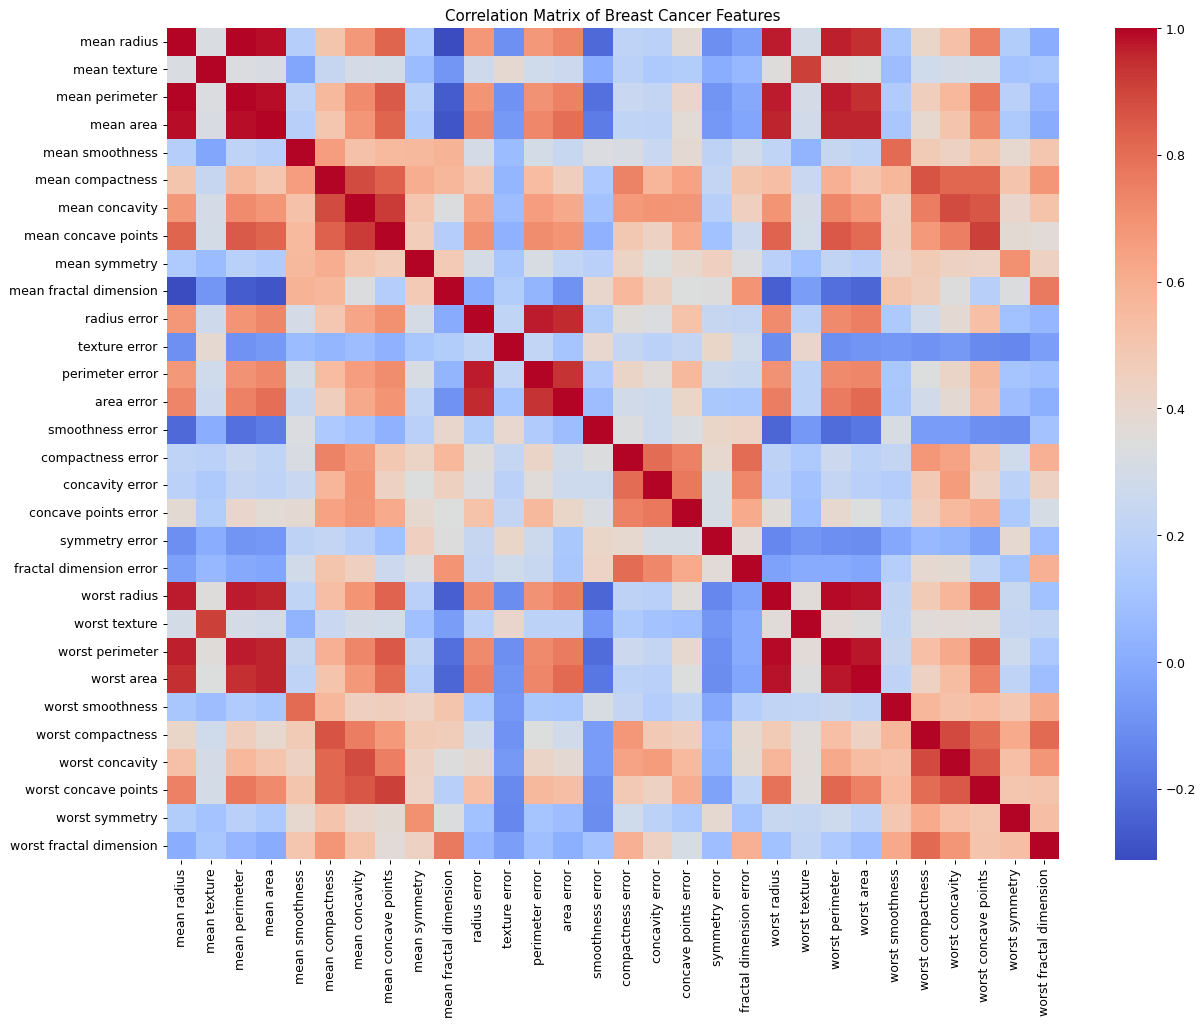

In [1]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix of Breast Cancer Features')
plt.show()

The heatmap shows dark red patches where two features are strongly positively correlated. Features related to the size of the tumor (`radius`, `perimeter`, `area`) form a clear red block, showing they carry very similar information.

## Identify Highly Correlated Features

We set a correlation threshold of **0.90**. Any pair of features whose correlation (positive or negative) is above this threshold is considered highly correlated / redundant.

In [1]:
threshold = 0.90
cols = corr_matrix.columns

corr_pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        value = corr_matrix.iloc[i, j]
        if abs(value) > threshold:
            corr_pairs.append((cols[i], cols[j], round(value, 4)))

print("Number of highly correlated pairs:", len(corr_pairs))
for pair in corr_pairs:
    print(pair)

Number of highly correlated pairs: 21
('mean radius', 'mean perimeter', np.float64(0.9979))
('mean radius', 'mean area', np.float64(0.9874))
('mean radius', 'worst radius', np.float64(0.9695))
('mean radius', 'worst perimeter', np.float64(0.9651))
('mean radius', 'worst area', np.float64(0.9411))
('mean texture', 'worst texture', np.float64(0.912))
('mean perimeter', 'mean area', np.float64(0.9865))
('mean perimeter', 'worst radius', np.float64(0.9695))
('mean perimeter', 'worst perimeter', np.float64(0.9704))
('mean perimeter', 'worst area', np.float64(0.9415))
('mean area', 'worst radius', np.float64(0.9627))
('mean area', 'worst perimeter', np.float64(0.9591))
('mean area', 'worst area', np.float64(0.9592))
('mean concavity', 'mean concave points', np.float64(0.9214))
('mean concave points', 'worst concave points', np.float64(0.9102))
('radius error', 'perimeter error', np.float64(0.9728))
('radius error', 'area error', np.float64(0.9518))
('perimeter error', 'area error', np.float6

There are **21 feature pairs** with correlation above 0.90 in the actual dataset. Most of them involve `radius`, `perimeter` and `area` (mean, error and worst versions), which makes sense since these three measurements describe the same physical property (tumor size) in different ways.

## Remove Highly Correlated Features

In [1]:
to_drop = set()
for f1, f2, value in corr_pairs:
    if f1 not in to_drop and f2 not in to_drop:
        to_drop.add(f2)

print("Features dropped due to high correlation:")
print(to_drop)
print("\nNumber of features dropped:", len(to_drop))

Features dropped due to high correlation:
{'mean area', 'mean perimeter', 'worst texture', 'mean concave points', 'perimeter error', 'worst radius', 'worst area', 'worst perimeter', 'area error'}

Number of features dropped: 9


In [1]:
X_corr_reduced = X.drop(columns=list(to_drop))
print("Before correlation-based reduction:", X.shape[1], "features")
print("After correlation-based reduction :", X_corr_reduced.shape[1], "features")

Before correlation-based reduction: 30 features
After correlation-based reduction : 21 features


**Interpretation:** 9 features (`mean area`, `mean perimeter`, `mean concave points`, `worst radius`, `worst perimeter`, `worst area`, `worst texture`, `perimeter error`, `area error`) were dropped because each of them was carrying almost the same information as another feature already kept (correlation above 0.90). This reduced the feature set from **30 to 21** features without throwing away any unique information.

## Variance Analysis / Variance Threshold

**Variance** tells us how spread out the values of a feature are. A feature with very low variance has almost the same value for every record, so it gives the model very little useful information to separate the classes.

We first look at the variance of each of the remaining 21 features, then apply `VarianceThreshold` from `sklearn.feature_selection` to automatically remove the low-variance ones.

In [1]:
X_corr_reduced.var().sort_values()

fractal dimension error     0.000007
smoothness error            0.000009
concave points error        0.000038
mean fractal dimension      0.000050
symmetry error              0.000068
mean smoothness             0.000198
compactness error           0.000321
worst fractal dimension     0.000326
worst smoothness            0.000521
mean symmetry               0.000752
concavity error             0.000911
mean compactness            0.002789
worst symmetry              0.003828
worst concave points        0.004321
mean concavity              0.006355
worst compactness           0.024755
worst concavity             0.043524
radius error                0.076902
texture error               0.304316
mean radius                12.418920
mean texture               18.498909
dtype: float64

The variance values above are on very different scales because the original features are measured in different units (some are ratios between 0 and 1, others are areas in the hundreds). Features like `fractal dimension error` and `smoothness error` have extremely small variance compared to `mean texture` or `mean radius`.

In [1]:
var_threshold = 0.001
selector = VarianceThreshold(threshold=var_threshold)
selector.fit(X_corr_reduced)

support = selector.get_support()
kept_columns = X_corr_reduced.columns[support]
dropped_columns = X_corr_reduced.columns[~support]

print("Variance threshold used:", var_threshold)
print("\nFeatures dropped (low variance):")
print(list(dropped_columns))
print("\nFeatures remaining:", len(kept_columns))
print(list(kept_columns))

Variance threshold used: 0.001

Features dropped (low variance):
['mean smoothness', 'mean symmetry', 'mean fractal dimension', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst smoothness', 'worst fractal dimension']

Features remaining: 10
['mean radius', 'mean texture', 'mean compactness', 'mean concavity', 'radius error', 'texture error', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry']


## Remove Low-Variance Features

In [1]:
X_final = X_corr_reduced[kept_columns]
print("Before variance threshold:", X_corr_reduced.shape[1], "features")
print("After variance threshold :", X_final.shape[1], "features")

Before variance threshold: 21 features
After variance threshold : 10 features


**Interpretation:** With a variance threshold of 0.001, **11 more features were removed** for having very little variation (values almost constant across all patients), leaving **10 features**. Combined with the correlation-based reduction, we have gone from the original **30 features down to just 10**, a reduction of about 67%.

## Model Performance Before Feature Selection

We use **Logistic Regression** since this is a binary classification problem (`malignant` vs `benign`), and it is the simplest classification model. We first train it using **all 30 original features**.

In [1]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_before = LogisticRegression(max_iter=5000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred_before)
print("Accuracy BEFORE feature selection (30 features):", accuracy_before)

Accuracy BEFORE feature selection (30 features): 0.956140350877193


## Model Performance After Feature Selection

Now we train the **same model** (`LogisticRegression`), with the **same `random_state=42`** and the **same train-test split ratio**, but using only the **10 features** that remained after correlation and variance-based feature selection.

In [1]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_final, y, test_size=0.2, random_state=42)

model_after = LogisticRegression(max_iter=5000)
model_after.fit(X_train2, y_train2)

y_pred_after = model_after.predict(X_test2)
accuracy_after = accuracy_score(y_test2, y_pred_after)
print("Accuracy AFTER feature selection (10 features):", accuracy_after)

Accuracy AFTER feature selection (10 features): 0.956140350877193


## Performance Comparison

In [1]:
comparison = pd.DataFrame({
    'Model': ['Before Feature Selection', 'After Feature Selection'],
    'Number of Features': [X.shape[1], X_final.shape[1]],
    'Accuracy': [accuracy_before, accuracy_after]
})
comparison

                      Model  Number of Features  Accuracy
0  Before Feature Selection                  30   0.95614
1   After Feature Selection                  10   0.95614

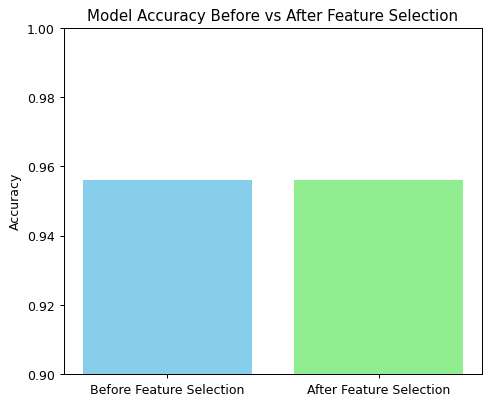

In [1]:
plt.figure(figsize=(6,5))
plt.bar(comparison['Model'], comparison['Accuracy'], color=['skyblue', 'lightgreen'])
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Before vs After Feature Selection')
plt.show()

## Results and Interpretation

- **Before feature selection:** 30 features, accuracy = **0.9561**
- **After feature selection:** 10 features, accuracy = **0.9561**

The accuracy of the Logistic Regression model is **exactly the same** before and after feature selection, even though the number of features was reduced by about 67% (from 30 down to 10).

This tells us that the 20 features which were removed (either because they were highly correlated with another feature, or because they had very low variance) were **not adding any new predictive information** that the remaining 10 features didn't already capture. The model performs equally well with a much simpler, smaller feature set - which means feature selection successfully reduced complexity **without any loss in performance**.

## Conclusion

In this FA1, we performed feature selection on the Breast Cancer dataset:

1. We explained why reducing the number of features is important (less redundancy, less noise, simpler models).
2. We generated a correlation matrix and dropped **9 highly correlated features** (correlation > 0.90), reducing the feature count from 30 to 21.
3. We applied the **variance threshold** method (threshold = 0.001) and dropped **11 more low-variance features**, reducing the count from 21 to 10.
4. We trained a Logistic Regression model before and after feature selection using the same train-test split, random state and evaluation metric, and found that **accuracy remained the same (0.9561) with 67% fewer features**.

This confirms that feature selection can significantly simplify a dataset while preserving model performance, by removing features that are either redundant or carry very little information.

---
<div align="center">

**Prof. Prakash Ukhalkar
 Course Teacher**
Advanced Data Science [MCA33PE17]

![](https://img.shields.io/badge/MCA33PE17-Advanced%20Data%20Science-blue?style=flat-square)
![](https://img.shields.io/badge/FA1-Feature%20Selection-green?style=flat-square)

</div>